<a href="https://colab.research.google.com/github/elonsobrevilla06-byte/pneumonia-classifier/blob/main/PneumoniaClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os
import kagglehub
from torch.utils.data import TensorDataset, random_split


In [4]:
path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [5]:
print("Path to dateset files:", path)

Path to dateset files: /kaggle/input/chest-xray-pneumonia


In [6]:
data_transforms = {
    "train":transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "test":transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    ])

}

In [7]:
import os
print(os.listdir(path))
print(os.listdir(os.path.join(path, "chest_xray")))

train_path_1 = os.path.join(path, "chest_xray", "train")
print("Level 1 train contents:", os.listdir(train_path_1))

train_path_2 = os.path.join(path, "chest_xray", "chest_xray", "train")
print("Level 2 train contents:", os.listdir(train_path_2))





['chest_xray']
['chest_xray', '__MACOSX', 'val', 'test', 'train']
Level 1 train contents: ['PNEUMONIA', 'NORMAL']
Level 2 train contents: ['PNEUMONIA', 'NORMAL', '.DS_Store']


In [9]:
data_dir = os.path.join(path, "chest_xray")

normal_path = os.path.join(data_dir, "train", "NORMAL")
pneumonia_path = os.path.join(data_dir, "train", "PNEUMONIA")

print(len(os.listdir(normal_path)), "normal images")
print(len(os.listdir(pneumonia_path)), "pneumonia images")
print(os.listdir(normal_path)[:5])





1341 normal images
3875 pneumonia images
['NORMAL2-IM-0771-0001.jpeg', 'NORMAL2-IM-1294-0001-0002.jpeg', 'IM-0675-0001.jpeg', 'NORMAL2-IM-1169-0001.jpeg', 'IM-0421-0001.jpeg']


In [10]:
full_train = datasets.ImageFolder(os.path.join(data_dir, "train"), data_transforms["train"])
print("full train", len(full_train))
val_size = int(0.15 * (len(full_train)))
train_size = len(full_train) - val_size

train_subset, val_subset = random_split(full_train, [train_size, val_size])

val_no_aug = datasets.ImageFolder(os.path.join(data_dir, "train"), data_transforms["val"])
val_subset.dataset = val_no_aug

test_subset = datasets.ImageFolder(os.path.join(data_dir, "test"), data_transforms["test"])

image_datasets = {"train": train_subset, "val": val_subset, "test": test_subset}

dataloaders = {
    x: torch.utils.data.DataLoader(
        image_datasets[x], batch_size=32, shuffle=True, num_workers=2
    )
    for x in ["train", "val", "test"]
}




full train 5216


In [32]:
dataset_sizes = {
    x: len(image_datasets[x]) for x in ["train", "test", "val"]
}

print(f"Dataset_sizes: {dataset_sizes}")

class_names = full_train.classes
print(f"Class names: {class_names}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Dataset_sizes: {'train': 4434, 'test': 624, 'val': 782}
Class names: ['NORMAL', 'PNEUMONIA']
Device: cuda:0


In [54]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
#if pretraned only use fc if not use bn and fc dont freeze them
for name, param in model.named_parameters():
    if "fc" in name:
      param.requires_grad =True
    else:
      param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

model = model.to(device)

device



/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


device(type='cuda', index=0)

In [55]:
best_val_acc = 0.0
best_model_weights = None

num_epochs = 1
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # keep the best model based on val accuracy, not train accuracy
        if phase == 'val' and epoch_acc > best_val_acc:
            best_val_acc = epoch_acc
            best_model_weights = model.state_dict()

model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), 'pneumonia_classifier.pth')

train Loss: 0.3802 Acc: 0.8433
val Loss: 0.2623 Acc: 0.8900


In [56]:
model = model.to(device)
model.eval()
running_corrects  = 0
with torch.no_grad():
  for inputs, labels in dataloaders['test']:
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    running_corrects += torch.sum(preds == labels.data)

test_acc = running_corrects.double() / dataset_sizes['test']
print(f'Test Accuracy: {test_acc:.4f}')


Test Accuracy: 0.8269


In [45]:
ckpt = torch.load('pneumonia_classifier.pth')
print(ckpt['fc.weight'].shape)

torch.Size([1000, 512])


# Testing


In [57]:
import torch
from torchvision import models, transforms
from PIL import Image

model = models.resnet18(pretrained = True)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(torch.load('pneumonia_classifier.pth'))
model.eval()

# new_model = models.resnet18(pretrained=True)
# new_model.fc = nn.Linear(new_model.fc.in_features, 2)

# new_model.fc.weight.data = model.fc.weight.data[0:2]
# new_model.fc.bias.data = model.fc.bias.data[0:2]



/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [58]:
image_path = 'pneumonia.jpeg'
image = Image.open(image_path)
preprocess = transforms.Compose([
         transforms.Grayscale(num_output_channels=3),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

input_tensor = preprocess(image)
print(input_tensor.shape)
input_batch = input_tensor.unsqueeze(0)
print(input_batch.shape)

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


In [66]:
import torch.nn.functional as F

with torch.no_grad():
  output = model(input_batch)
  probs = F.softmax(output, dim = 1)[0]

_, predicted_class = output.max(1)

class_names = ['Normal', 'Pneumonia']
predicted_label = class_names[predicted_class.item()]
confidence = probs[predicted_class].item() *100

print(f'Predicted Class: {predicted_label} ({confidence:.2f}% confidence)')

for name, p in zip(class_names, probs):
  print(f'{name}: {p.item()*100:.2f}%')



Predicted Class: Pneumonia (97.45% confidence)
Normal: 2.55%
Pneumonia: 97.45%


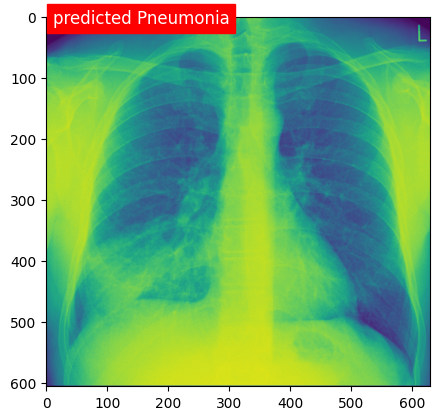

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = np.array(image)
plt.imshow(image)
plt.text(10,10, f"predicted {predicted_label}", fontsize=12, color = 'white' , backgroundcolor = 'red')
plt.show()
